In [7]:
import torch
import numpy as np
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.linear_model import LinearRegression

import matplotlib as mpl
import matplotlib.pyplot as plt

import os
import json


mpl.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "Helvetica",
    }
)

with open(
    "/Users/henrywilliams/Documents/programming/python/ai/malbert-test/notebooks/obfuscation-experiment-files.json",
    "r",
) as file:
    dataset = json.load(file)


In [8]:
results = {
    "base": {
        "all": "/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/base-all",
        "benign": "/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/base-benign",
        "malicious": "/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/base-malicious",
    },
    "filtered": {
        "all": "/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/filtered-all",
        "benign": "/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/filtered-benign",
        "malicious": "/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/filtered-malicious",
    },
}

In [9]:
def get_results(results_path):
    return [
        os.path.join(results_path, file)
        for file in os.listdir(results_path)
        if not file.startswith(".")
    ]

In [ ]:
def get_accuracy(results_path):
    with open(os.path.join(results_path, "results.json"), "r") as results:
        results = json.load(results)

    return [result["macro avg"]["f1-score"] for result in results]

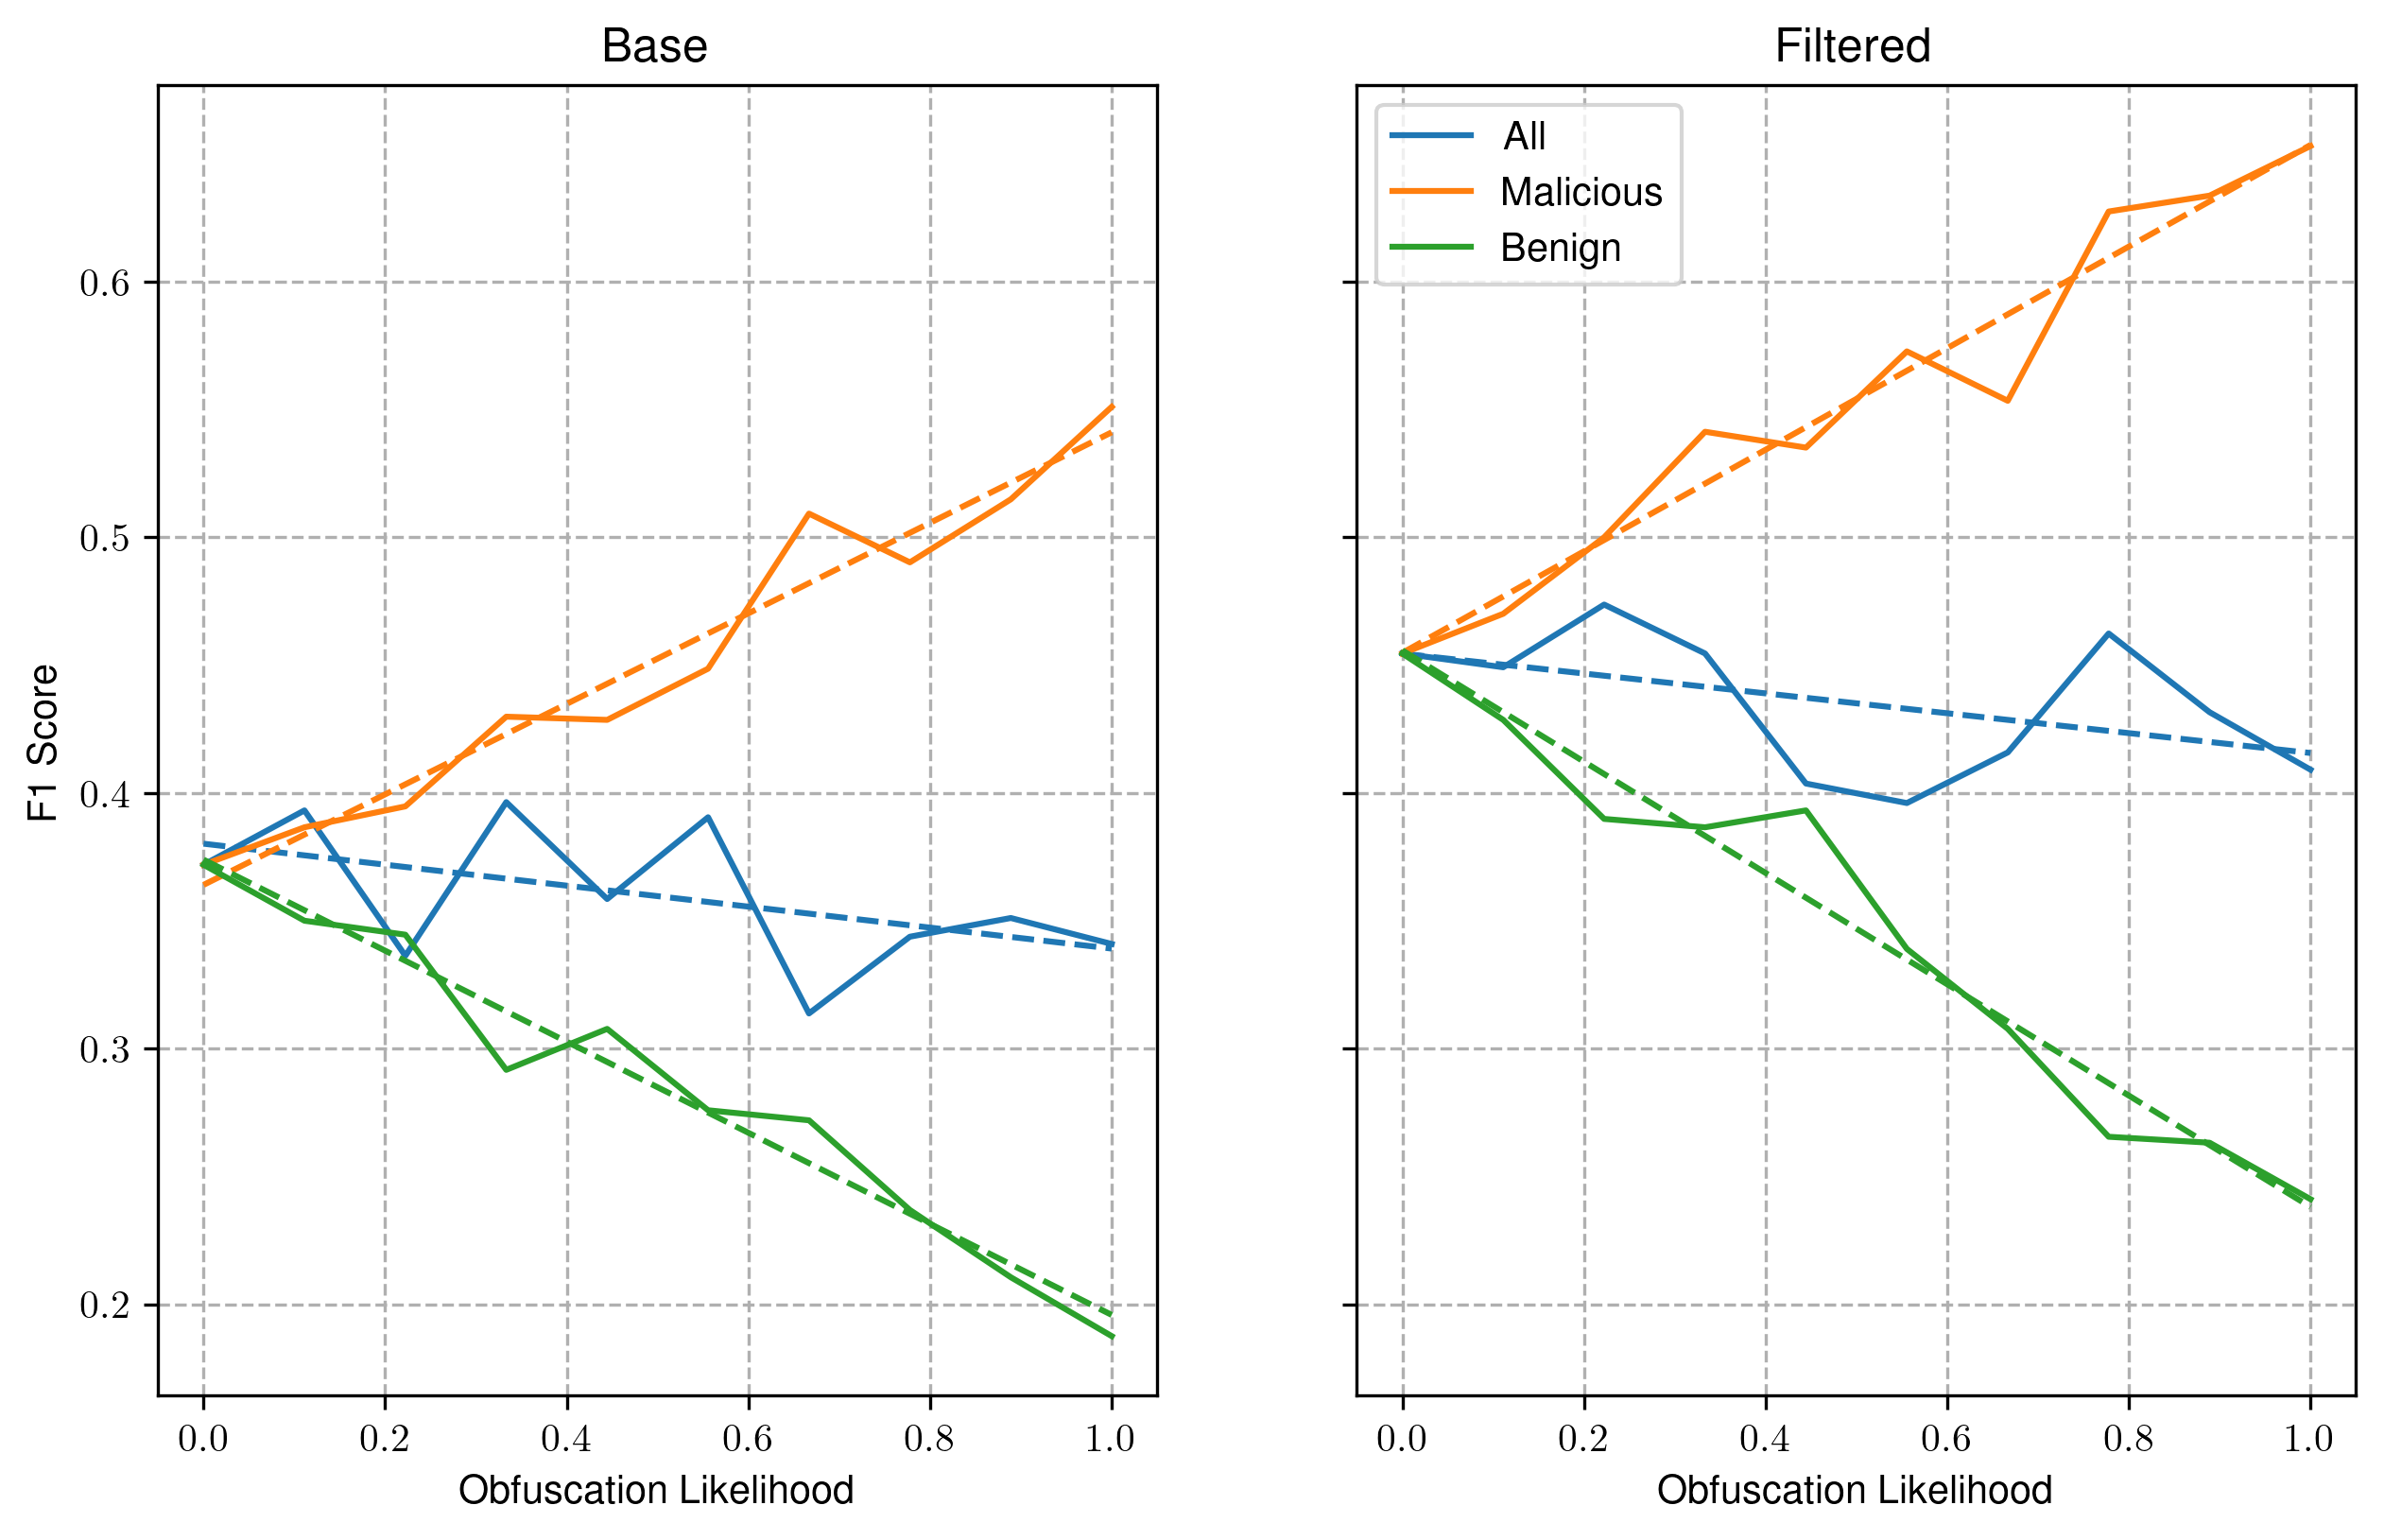

In [15]:
fig, axs = plt.subplots(1, 2, dpi=300, sharey=True, sharex=True, figsize=(10, 6))
# fig.suptitle("File-level classification accuracy")
ps = np.linspace(0.0, 1.0, 10)
axs[0].set_ylabel("F1 Score")
for i, m in enumerate(["base", "filtered"]):
    axs[i].title.set_text(m.title())
    axs[i].grid(linestyle="--")
    axs[i].set_xlabel("Obfuscation Likelihood")
    for l in ["all", "malicious", "benign"]:
        acc = get_accuracy(results[m][l])
        reg = LinearRegression().fit(ps.reshape(-1, 1), acc)
        plot = axs[i].plot(ps, acc, label=l.title())
        axs[i].plot(
            ps, reg.predict(ps.reshape(-1, 1)), linestyle="--", c=plot[0].get_color()
        )
axs[1].legend()
fig.savefig(
    "/Users/henrywilliams/Documents/uni/masters-thesis/writing/thesis/assets/img-obf-file-level-f1-score.png"
)
plt.show()

In [12]:
def get_step(results_path, step):
    return os.path.join(results_path, f"step-{step}")


def get_logit_paths(results_path, step=0):
    path = get_step(results_path, step)
    logits_path = os.path.join(path, "logits")
    logit_files = [
        os.path.join(logits_path, file)
        for file in os.listdir(logits_path)
        if file.endswith(".pt")
    ]
    return sorted(logit_files, key=lambda file: os.path.getctime(file))

In [13]:
def get_avg_certainty_at_step(results_path, step=0):
    logit_files = get_logit_paths(results_path, step)
    certainty = []

    for file in logit_files:
        logits = torch.load(file)
        probs = F.softmax(logits, dim=1)
        uniform = torch.full_like(probs, 0.5)

        kl_div = F.kl_div(uniform.log(), probs, reduction="none").sum(
            dim=1
        )  # KL(p || u)
        certainty.append(kl_div.mean().item())

    return np.mean(certainty), np.std(certainty)


def get_avg_certainty(results_path):
    with open(os.path.join(results_path, "config.json"), "r") as f:
        config = json.load(f)

    return [get_avg_certainty_at_step(results_path, i) for i in range(config["steps"])]

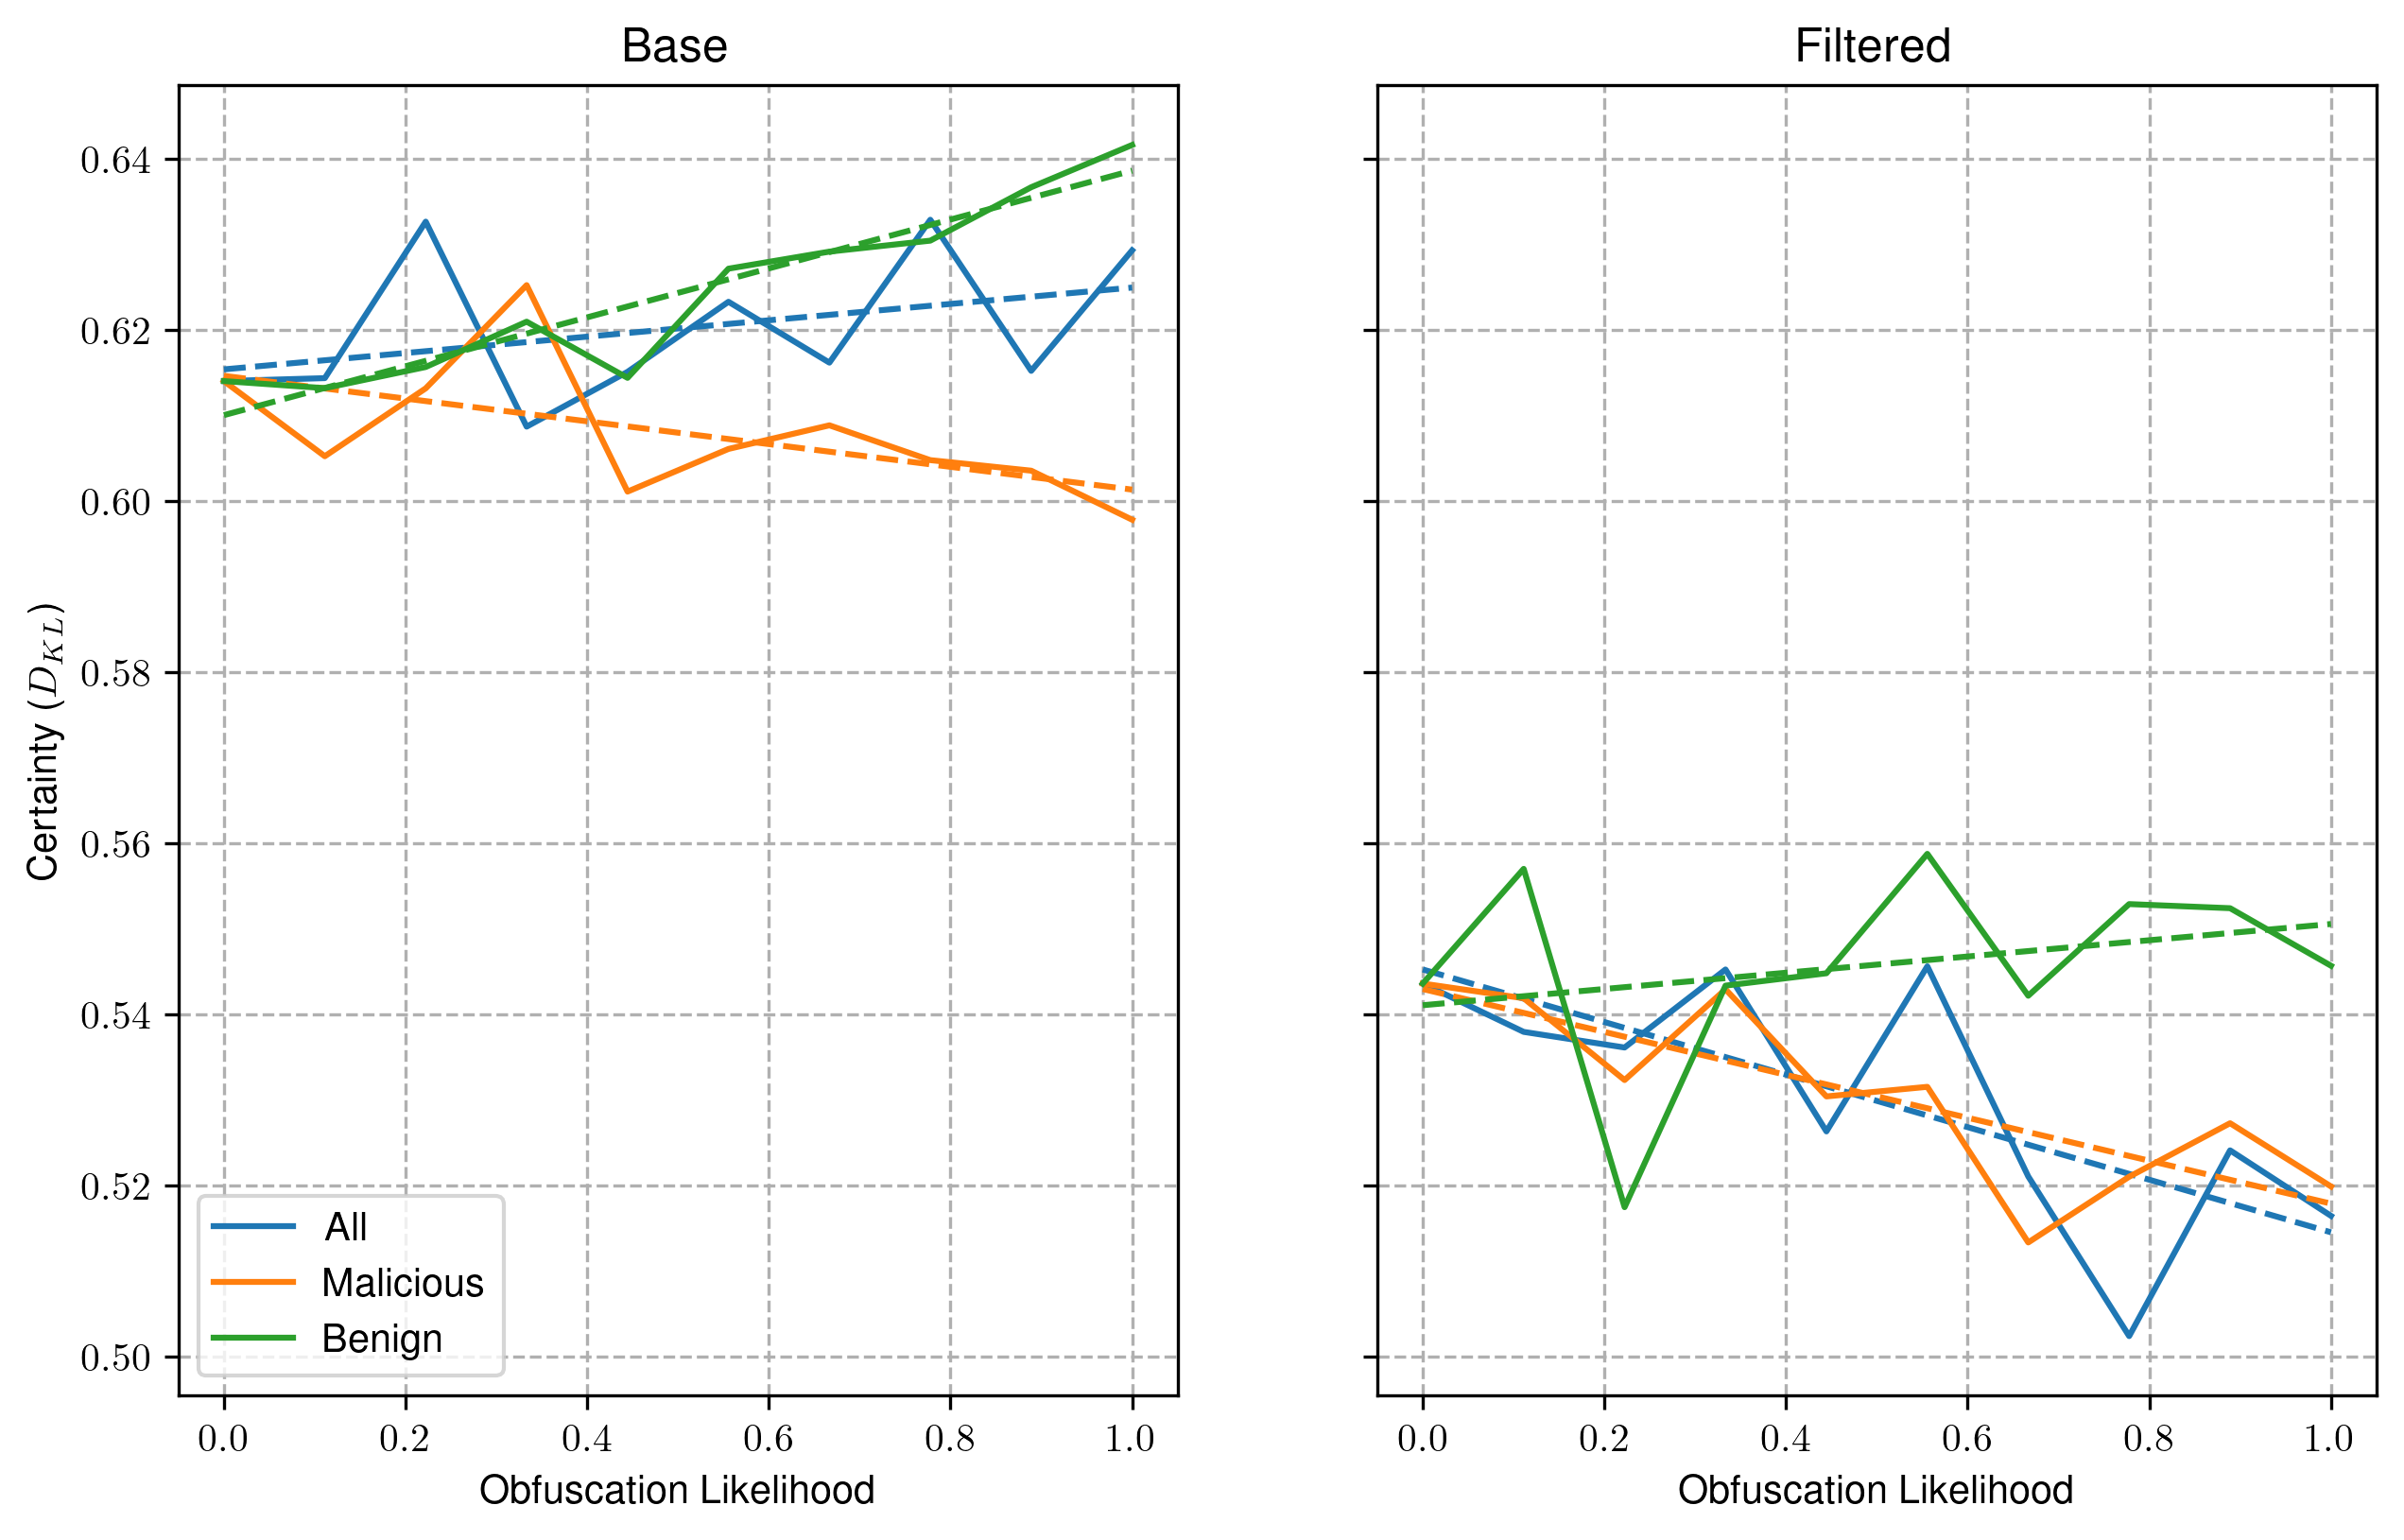

In [ ]:
fig, axs = plt.subplots(1, 2, dpi=300, sharey=True, sharex=True, figsize=(10, 6))
# fig.suptitle("Average certainty in predictions")
ps = np.linspace(0.0, 1.0, 10)
axs[0].set_ylabel(r"Certainty ($D_{KL}$)")
loop = tqdm(desc="Generating plot...", total=6, leave=False)

for i, m in enumerate(["base", "filtered"]):
    axs[i].title.set_text(m.title())
    axs[i].grid(linestyle="--")
    axs[i].set_xlabel("Obfuscation Likelihood")

    for l in ["all", "malicious", "benign"]:
        certainty = np.array(get_avg_certainty(results[m][l]))
        mean = certainty[:, 0]
        reg = LinearRegression().fit(ps.reshape(-1, 1), mean)
        plot = axs[i].plot(ps, mean, label=l.title())
        axs[i].plot(
            ps, reg.predict(ps.reshape(-1, 1)), linestyle="--", c=plot[0].get_color()
        )
        loop.update(1)
axs[0].legend()
fig.savefig(
    "/Users/henrywilliams/Documents/uni/masters-thesis/writing/thesis/assets/img-obf-certainty.png"
)
plt.show()